In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


SyntaxError: invalid syntax (3936815611.py, line 4)

In [14]:
df = pd.read_csv('Amazon sales.csv')

In [15]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           100000 non-null  str    
 17  State          100000 non-null  str    
 

In [17]:
# Eliminamos la columna 'Country'
df = df.drop('Country', axis=1)
print(df.shape)

(100000, 19)


In [18]:
# Sobrescribimos la columna OrderDate convirtiéndola a formato fecha
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
print(df['OrderDate'].dtype)

datetime64[us]


In [19]:
print("--- VALORES NULOS ---")
print(df.isnull().sum())

print("\n--- FILAS DUPLICADAS ---")
print(df.duplicated().sum())

print("\n--- ESTADÍSTICAS BÁSICAS ---")
df.describe()

--- VALORES NULOS ---
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
SellerID         0
dtype: int64

--- FILAS DUPLICADAS ---
0

--- ESTADÍSTICAS BÁSICAS ---


,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.439999,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [20]:

print("Pedidos únicos:", df['OrderID'].nunique())
print("Clientes únicos:", df['CustomerID'].nunique())
print("Productos distintos:", df['ProductID'].nunique())

Pedidos únicos: 100000
Clientes únicos: 43233
Productos distintos: 50


## 1º - El impacto real de las ofertas

   Discount  Quantity  TotalAmount
0      0.00  3.005938   987.906980
1      0.05  2.995123   942.945836
2      0.10  2.998726   898.122127
3      0.15  2.999104   841.706168
4      0.20  2.993576   793.679578
5      0.25  2.996189   746.731145
6      0.30  3.048265   726.645395


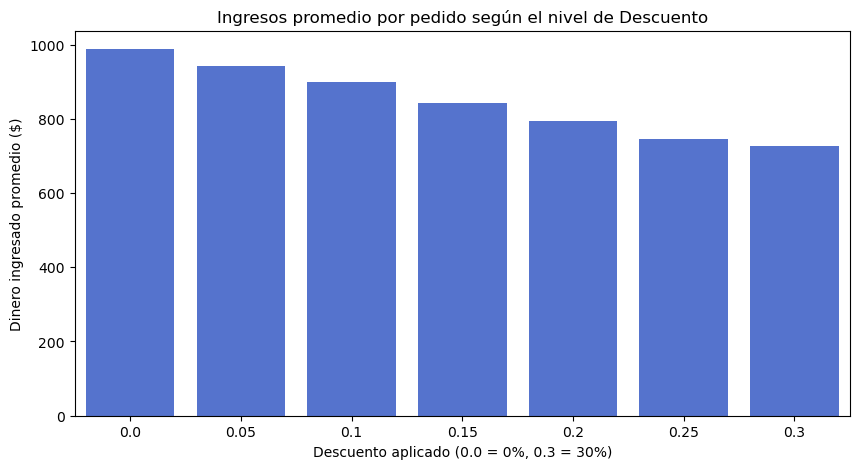

In [21]:
# 1. Agrupamos los pedidos según el descuento que tuvieron
# y calculamos la media (mean) de la cantidad comprada y el dinero total.
analisis_descuentos = df.groupby('Discount')[['Quantity', 'TotalAmount']].mean().reset_index()

# 2. Mostramos la tabla resumen
print(analisis_descuentos)

# 3. Vamos a dibujarlo para que sea visualmente impactante
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño del lienzo
plt.figure(figsize=(10, 5))

# Creamos un gráfico de barras
sns.barplot(data=analisis_descuentos, x='Discount', y='TotalAmount', color='royalblue')

# Ponemos títulos para que se entienda
plt.title('Ingresos promedio por pedido según el nivel de Descuento')
plt.xlabel('Descuento aplicado (0.0 = 0%, 0.3 = 30%)')
plt.ylabel('Dinero ingresado promedio ($)')

# Mostramos el gráfico
plt.show()

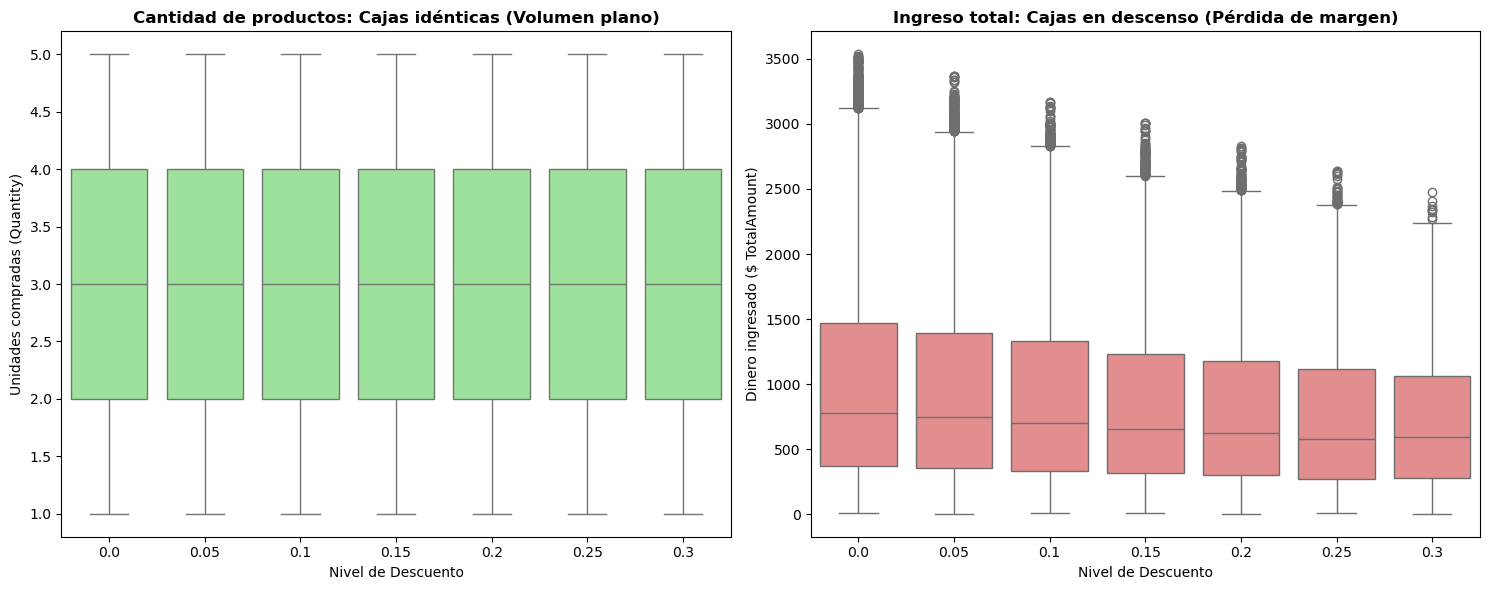

In [22]:


# Creamos un lienzo amplio con 1 fila y 2 columnas para poner los gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1 (Izquierda): Distribución de la Cantidad según el Descuento
sns.boxplot(data=df, x='Discount', y='Quantity', ax=axes[0], color='lightgreen')
axes[0].set_title('Cantidad de productos: Cajas idénticas (Volumen plano)', fontweight='bold')
axes[0].set_xlabel('Nivel de Descuento')
axes[0].set_ylabel('Unidades compradas (Quantity)')

# Gráfico 2 (Derecha): Distribución del Ingreso Total según el Descuento
sns.boxplot(data=df, x='Discount', y='TotalAmount', ax=axes[1], color='lightcoral')
axes[1].set_title('Ingreso total: Cajas en descenso (Pérdida de margen)', fontweight='bold')
axes[1].set_xlabel('Nivel de Descuento')
axes[1].set_ylabel('Dinero ingresado ($ TotalAmount)')

# Ajustamos los márgenes para que no se pisen los textos y mostramos
plt.tight_layout()
plt.show()

Se demuestra que los descuentos no tienen ningún impacto en la compra.
- Los clientes compran de media la misma cantidad de articulos, independientemente del desceunto existiente.
- Lo único que provoca es un mejor ingreso y por tanto, menor margen de beneficio.

--------------------------------

## 2º - Segmentación de Clientes (Modelo RFM)

In [23]:
# 1. Para calcular los días que hace desde la última compra, necesitamos un "hoy" ficticio.
# Usamos el día más reciente de todo nuestro dataset sumándole 1 día.
fecha_actual = df['OrderDate'].max() + pd.Timedelta(days=1)

# 2. Agrupamos por cliente y calculamos las 3 métricas de golpe
rfm = df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (fecha_actual - x.max()).days,  # R: Días desde su última compra
    'OrderID': 'count',                                    # F: Cantidad total de pedidos
    'TotalAmount': 'sum'                                   # M: Suma total de dinero gastado
}).reset_index()

# 3. Renombramos las columnas para que sean fáciles de leer
rfm.columns = ['CustomerID', 'Recencia', 'Frecuencia', 'Valor_Monetario']

# Mostramos a los 5 primeros clientes
print(rfm.head())

   CustomerID  Recencia  Frecuencia  Valor_Monetario
0  CUST000001       157           1           446.48
1  CUST000002      1063           3          1389.93
2  CUST000003      1463           1          1116.91
3  CUST000004       196           3          2660.06
4  CUST000005       640           1          1089.56


Recencia (R): Le daremos un 3 al que compró hace poco, y un 1 al que hace años que no nos visita.

Frecuencia (F): Le daremos un 3 al que ha comprado muchas veces, y un 1 al que solo compró una vez.

Monetización (M): Le daremos un 3 al que ha gastado muchísimo dinero, y un 1 al que ha gastado céntimos.

Al juntar esas tres notas, un cliente VIP será un 3-3-3 (compra mucho, gasta mucho y compró hace poco). Un cliente perdido será un 1-1-1

In [25]:
# 1. Puntuamos la Recencia (R): dividimos en 3 trozos iguales.
# Aquí menos días es mejor, por eso las etiquetas son 3 (mejor), 2, 1 (peor)
rfm['R_Score'] = pd.qcut(rfm['Recencia'], q=3, labels=[3, 2, 1])

# 2. Puntuamos la Frecuencia (F): 
# 1 = Solo 1 compra, 2 = Entre 2 y 3 compras, 3 = Más de 3 compras
rfm['F_Score'] = pd.cut(rfm['Frecuencia'], bins=[0, 1, 3, 100], labels=[1, 2, 3])

# 3. Puntuamos la Monetización (M): dividimos por dinero gastado en 3 niveles
rfm['M_Score'] = pd.qcut(rfm['Valor_Monetario'], q=3, labels=[1, 2, 3])

# 4. Juntamos los tres números para crear su código de grupo final (ejemplo: "333")
rfm['Grupo_RFM'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 5. Les ponemos nombres humanos a los grupos principales
def asignar_nombre(codigo):
    if codigo == '333': return 'VIP (Compran mucho, reciente y caro)'
    if codigo == '111': return 'Perdidos (Compraron una vez hace mucho)'
    if codigo.startswith('3') and codigo.endswith('1'): return 'Nuevos (Compraron hace poco pero barato)'
    if codigo.startswith('1') and codigo.endswith('3'): return 'Eventual (Gastaban mucho pero hace tiempo que no vienen)'
    return 'Clientes Promedio (Resto)'

rfm['Segmento'] = rfm['Grupo_RFM'].apply(asignar_nombre)

# 6. Contamos cuántos clientes hay en cada grupo
print("--- DISTRIBUCIÓN DE CLIENTES POR GRUPO ---")
print(rfm['Segmento'].value_counts())

--- DISTRIBUCIÓN DE CLIENTES POR GRUPO ---
Segmento
Clientes Promedio (Resto)                                   28532
Perdidos (Compraron una vez hace mucho)                      5297
VIP (Compran mucho, reciente y caro)                         3373
Nuevos (Compraron hace poco pero barato)                     3277
Eventual (Gastaban mucho pero hace tiempo que no vienen)     2754
Name: count, dtype: int64


Tenemos clientes en los que necesitamos mantenerlos y proetgerlos (Clientes VIP) y el grupo de clientes promedio (Resto) son los que tenemos que impactar las ofertas y promociones para fidelizarlos y convertirlos en VIP. El grupo de Eventual y de Perdidos no interesa impactar ya que son mas dificiles de atraer, porque o tuvieron mala experiencia de compra, o solo compraron por una oferta puntual, lo que no impacta en el margen de beneficios.

-------------------------------------------------

## 3º - Detección de cuellos de botella logísticos

 SellerID  Total_Ventas  Total_Fallos  Tasa_Fallo_%
SELL01533            50             9     18.000000
SELL01444            52             9     17.307692
SELL01578            53             9     16.981132
SELL00530            54             9     16.666667
SELL01066            57             9     15.789474
SELL01979            51             8     15.686275
SELL01742            53             8     15.094340
SELL01014            54             8     14.814815
SELL00266            54             8     14.814815
SELL01057            61             9     14.754098


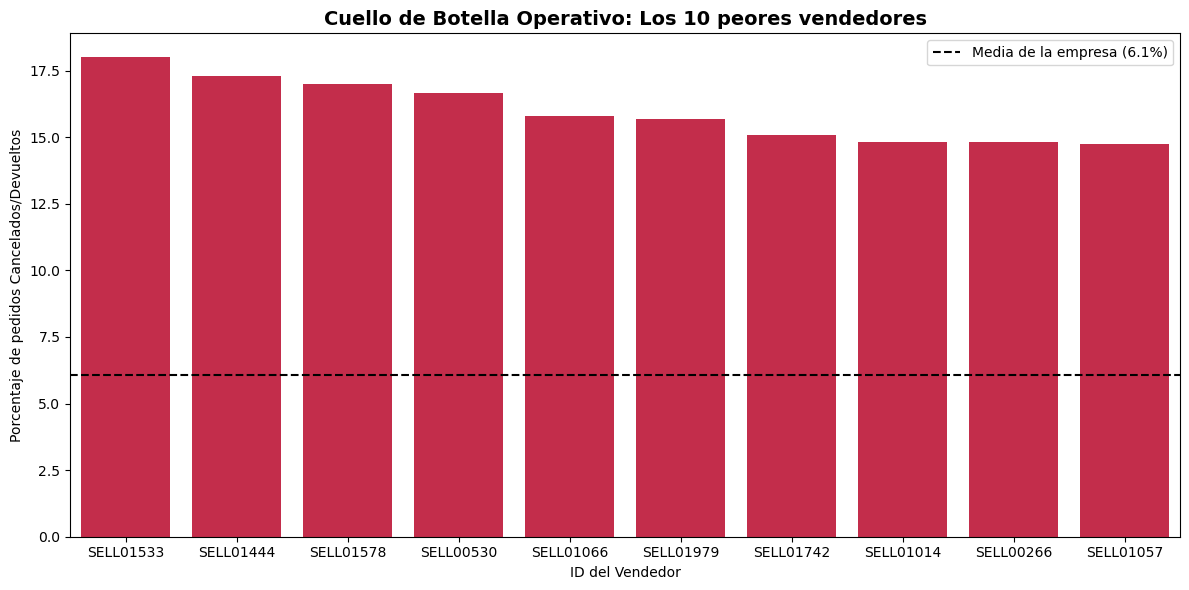

In [38]:
# 1. Creamos una nueva columna que sea True solo si el pedido fue cancelado o devuelto
df['Fallo_Logistico'] = df['OrderStatus'].isin(['Cancelled', 'Returned'])

# 2. Agrupamos por VENDEDOR para ver quién falla más
# Filtramos solo a los vendedores que tengan al menos 50 ventas (no castigar a alguien que vendió 1 cosa y se la devolvieron)
vendedores = df.groupby('SellerID').agg(
    Total_Ventas=('OrderID', 'count'),
    Total_Fallos=('Fallo_Logistico', 'sum')
)
vendedores = vendedores[vendedores['Total_Ventas'] >= 50]

# Calculamos el porcentaje de fallo
vendedores['Tasa_Fallo_%'] = (vendedores['Total_Fallos'] / vendedores['Total_Ventas']) * 100

# Ordenamos de peor a mejor y cogemos a los 10 peores
peores_vendedores = vendedores.sort_values('Tasa_Fallo_%', ascending=False).head(10).reset_index()

print(peores_vendedores.to_string(index=False))
# 3. Dibujamos el "Muro de la Vergüenza"
plt.figure(figsize=(12, 6))
sns.barplot(data=peores_vendedores, x='SellerID', y='Tasa_Fallo_%', color='crimson')

# Añadimos una línea horizontal que muestre la media general de fallos de la empresa (aprox 6%)
tasa_media = (df['Fallo_Logistico'].sum() / len(df)) * 100
plt.axhline(tasa_media, color='black', linestyle='--', label=f'Media de la empresa ({tasa_media:.1f}%)')

plt.title('Cuello de Botella Operativo: Los 10 peores vendedores', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje de pedidos Cancelados/Devueltos')
plt.xlabel('ID del Vendedor')
plt.legend()
plt.tight_layout()
plt.show()